In [1]:
%pip install matplotlib
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd  # Importa o Pandas para ler o arquivo CSV que você criou
import numpy as np   # Importa o Numpy para realizar os cálculos matemáticos (raiz, soma, etc)
import matplotlib.pyplot as plt  # Importa o Matplotlib para desenhar o gráfico final

## -------------------------------------------------------------

# Exercicio 1.

## -------------------------------------------------------------

In [3]:
try:
    dados = np.loadtxt('dataset_exercicio_1.csv', delimiter=',', skiprows=1)
    print("Dados carregados com sucesso!")
except Exception as e:
    print(f"Erro ao carregar o arquivo: {e}")

Dados carregados com sucesso!


Coeficiente Angular (a): 3.6570
Intercepto (b): 13.0407
Equação da Reta: y = 3.66x + 13.04


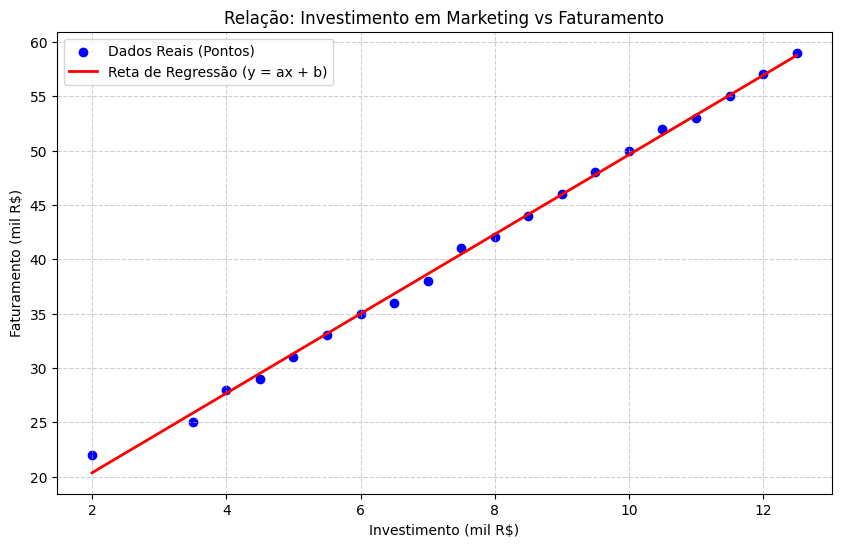

In [8]:
# 1. CARREGAMENTO DOS DADOS
# np.genfromtxt lê o arquivo. delimiter=',' define a vírgula como separador.
# skip_header=1 pula a primeira linha (cabeçalho com os nomes das colunas).
dados = np.genfromtxt('dataset_exercicio_1.csv', delimiter=',', skip_header=1)

# Extraímos a primeira coluna [:, 0] como nossa variável independente X (Investimento) [cite: 1]
X = dados[:, 0] 
# Extraímos a segunda coluna [:, 1] como nossa variável dependente y (Faturamento) [cite: 1]
y = dados[:, 1] 

# 2. CÁLCULO DOS COEFICIENTES (MATEMÁTICA DA REGRESSÃO)
# Calculamos a média de X (investimento médio) e de y (faturamento médio)
x_mean = np.mean(X)
y_mean = np.mean(y)

# Fórmula da Inclinação (a): somatório de [(x - média_x) * (y - média_y)] / somatório de [(x - média_x)^2]
# Isso mede a variação de y em relação a x.
numerador = np.sum((X - x_mean) * (y - y_mean))
denominador = np.sum((X - x_mean)**2)
a = numerador / denominador  # Este é o nosso coeficiente angular (slope)

# Fórmula do Intercepto (b): média_y - (inclinação * média_x)
# É onde a reta toca o eixo vertical (valor de y quando X é zero).
b = y_mean - a * x_mean

# 3. PREVISÃO
# Criamos a reta de regressão aplicando os valores de a e b encontrados na fórmula y = ax + b
y_pred = a * X + b

# 4. EXIBIÇÃO DOS RESULTADOS NO CONSOLE
print(f"Coeficiente Angular (a): {a:.4f}") # Mostra quanto o faturamento cresce por real investido
print(f"Intercepto (b): {b:.4f}")          # Mostra o faturamento base estimado
print(f"Equação da Reta: y = {a:.2f}x + {b:.2f}")

# 5. CONSTRUÇÃO DO GRÁFICO
plt.figure(figsize=(10, 6)) # Define o tamanho da janela do gráfico

# plt.scatter desenha os pontos individuais (os dados reais do CSV) 
plt.scatter(X, y, color='blue', label='Dados Reais (Pontos)')

# plt.plot desenha a linha contínua (o modelo de regressão que calculamos)
plt.plot(X, y_pred, color='red', linewidth=2, label='Reta de Regressão (y = ax + b)')

# Customização de etiquetas para a prova
plt.title('Relação: Investimento em Marketing vs Faturamento') # Título do gráfico
plt.xlabel('Investimento (mil R$)') # Nome do eixo X
plt.ylabel('Faturamento (mil R$)')   # Nome do eixo Y
plt.legend() # Mostra a legenda (box com nomes das cores)
plt.grid(True, linestyle='--', alpha=0.6) # Adiciona uma grade ao fundo para facilitar a leitura

# Exibe o gráfico finalizado
plt.show()

a) Existe correlação entre os valores investidos e o faturamento?
Sim. Existe uma correlação positiva forte. O gráfico mostra que quanto mais se investe em marketing, mais o faturamento aumenta de forma constante.
b) Como interpretar o coeficiente de inclinação ($a$)?
Ele representa o retorno por real investido. Se $a = 3.53$, significa que para cada R$ 1.000 investidos, o faturamento cresce R$ 3.530.
c) Qual o significado do intercepto ($b$)?
É o faturamento inicial. Representa quanto a empresa faturaria se o investimento em marketing fosse zero.
d) O modelo é adequado para prever resultados futuros?
Sim. Os dados estão muito próximos da reta (baixo erro), o que torna as previsões do modelo confiáveis.
e) Qual a principal conclusão para o gestor?
O marketing digital funciona como um motor de crescimento previsível. O gestor pode aumentar o investimento com segurança, pois há um retorno claro e linear no faturamento.

## -------------------------------------------------------------

# Exercicio 2.

## -------------------------------------------------------------

Inclinação (Aumento por ano): R$ 0.57 mil
Salário Inicial Estimado (b): R$ 2.27 mil
Equação: Salário = 0.57 * Experiência + 2.27


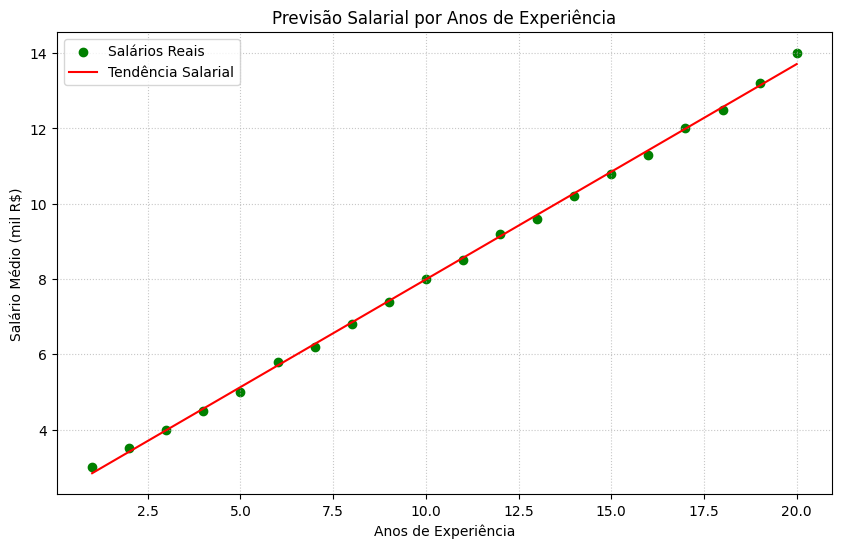

In [12]:
# 1. CARREGAMENTO DOS DADOS
# Usamos o arquivo 'dataset_exercicio_2.csv'
# skip_header=1 ignora a primeira linha que contém os nomes das colunas
dados_rh = np.genfromtxt('dataset_exercicio_2.csv', delimiter=',', skip_header=1)

# X representa os anos de experiência (primeira coluna)
X = dados_rh[:, 0] 
# y representa o salário médio (segunda coluna)
y = dados_rh[:, 1] 

# 2. CÁLCULO DOS COEFICIENTES (Equação da Reta: y = ax + b)
# Primeiro, calculamos as médias necessárias para as fórmulas
x_mean = np.mean(X)
y_mean = np.mean(y)

# Cálculo da Inclinação (a): mede o aumento salarial por cada ano de experiência
# Fórmula: soma de (x - média_x) * (y - média_y) dividido pela soma de (x - média_x)²
numerador = np.sum((X - x_mean) * (y - y_mean))
denominador = np.sum((X - x_mean)**2)
a = numerador / denominador

# Cálculo do Intercepto (b): o salário teórico inicial (com 0 anos de experiência)
# Fórmula: média_y - (inclinação * média_x)
b = y_mean - a * x_mean

# 3. CRIAÇÃO DO MODELO DE PREVISÃO
# Aplicamos os coeficientes encontrados para criar a reta que melhor se ajusta aos pontos
y_pred = a * X + b

# 4. EXIBIÇÃO DOS RESULTADOS (Para conferência)
print(f"Inclinação (Aumento por ano): R$ {a:.2f} mil")
print(f"Salário Inicial Estimado (b): R$ {b:.2f} mil")
print(f"Equação: Salário = {a:.2f} * Experiência + {b:.2f}")

# 5. GERANDO O GRÁFICO PARA ANÁLISE
plt.figure(figsize=(10, 6)) # Define o tamanho da imagem

# Plota os dados reais como pontos azuis
plt.scatter(X, y, color='green', label='Salários Reais') 

# Plota a linha de previsão em vermelho
plt.plot(X, y_pred, color='red', label='Tendência Salarial')

# Configurações de visualização
plt.title('Previsão Salarial por Anos de Experiência')
plt.xlabel('Anos de Experiência')
plt.ylabel('Salário Médio (mil R$)')
plt.legend() # Exibe a legenda do gráfico
plt.grid(True, linestyle=':', alpha=0.7) # Adiciona uma grade pontilhada
plt.show()

## -------------------------------------------------------------

# Exercicio 3.

## -------------------------------------------------------------

Coeficiente de Impacto (a): 1.86 pontos por treinamento
Desempenho Base (b): 57.81 pontos
Modelo Matemático: Desempenho = 1.86 * Treinamentos + 57.81


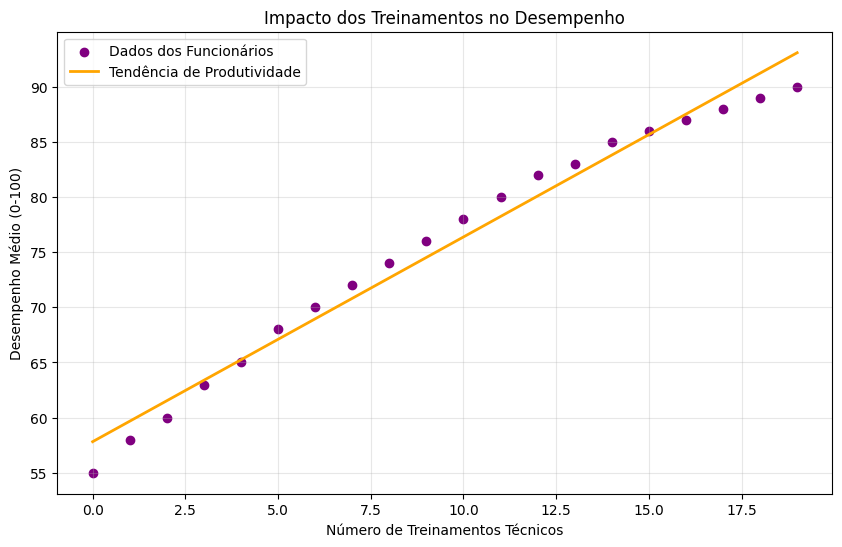

In [11]:
# 1. CARREGAMENTO DOS DADOS
# Lendo o arquivo 'dataset_exercicio_3.csv'
# skip_header=1 pula os nomes das colunas: 'Treinamentos' e 'Desempenho'
dados_produtividade = np.genfromtxt('dataset_exercicio_3.csv', delimiter=',', skip_header=1)

# X = Quantidade de treinamentos (Variável Independente)
X = dados_produtividade[:, 0] 
# y = Produtividade/Desempenho (Variável Dependente)
y = dados_produtividade[:, 1] 

# 2. MATEMÁTICA DA REGRESSÃO (Encontrando a Reta)
# Calculamos as médias de X e y
x_mean = np.mean(X)
y_mean = np.mean(y)

# Cálculo da Inclinação (a): Representa o ganho de desempenho por cada treinamento feito
# Numerador: soma de (cada x - média) * (cada y - média)
numerador = np.sum((X - x_mean) * (y - y_mean))
# Denominador: soma de (cada x - média)²
denominador = np.sum((X - x_mean)**2)
a = numerador / denominador

# Cálculo do Intercepto (b): O desempenho base do funcionário com ZERO treinamentos
b = y_mean - a * x_mean

# 3. PREDIÇÃO DO MODELO
# Criamos a reta ideal: y = ax + b
y_pred = a * X + b

# 4. EXIBIÇÃO DOS RESULTADOS (Checklist para a prova)
print(f"Coeficiente de Impacto (a): {a:.2f} pontos por treinamento")
print(f"Desempenho Base (b): {b:.2f} pontos")
print(f"Modelo Matemático: Desempenho = {a:.2f} * Treinamentos + {b:.2f}")

# 5. GRÁFICO DE CORRELAÇÃO
plt.figure(figsize=(10, 6)) # Cria o espaço do gráfico

# Plota os pontos reais dos funcionários
plt.scatter(X, y, color='purple', label='Dados dos Funcionários') 

# Plota a reta que resume a tendência
plt.plot(X, y_pred, color='orange', label='Tendência de Produtividade', linewidth=2)

# Detalhes visuais importantes para o relatório
plt.title('Impacto dos Treinamentos no Desempenho')
plt.xlabel('Número de Treinamentos Técnicos')
plt.ylabel('Desempenho Médio (0-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()